- 线性回归适用: 有监督学习,标签连续,回归问题
    - 一元线性回归(单特征线性回归) y=wx+b
    - 多元线性回归(多特征线性回归) y=w1x1+w2x2+...+wnxn+b
    - w称为权重(coef_), b称为偏置(intercept_)

- 损失函数: 衡量点到回归线的距离,衡量拟合线与数据点的差距,目的找损失函数最小
    - 正规方程: 基于公式计算(求极值点)
    - 梯度下降算法

- 评估指标: 衡量模型性能
    - 均方误差(MSE): 预测值与真实值差的平方的平均值
    - 平均绝对误差(MAE): 预测值与真实值差的绝对值的平均值
    - 均方根误差(RMSE): 均方误差的平方根,与原始数据单位相同

- 欠拟合与过拟合
    - L1正则化(套索回归): 通过增加绝对值惩罚项,使某些特征权重变为零,实现特征选择
    - L2正则化(岭回归): 通过增加平方惩罚项,使模型权重更小

In [76]:
from sklearn.linear_model import LinearRegression

# 1. 准备数据
x_train = [[160], [166], [172], [174], [180]]
y_train = [56.3, 60.6, 65.1, 68.5, 75]
x_test = [[176]]

# 2. 数据预处理

# 3. 特征工程

# 4. 模型选择
model = LinearRegression()

# 5. 模型预测,评估
model.fit(x_train, y_train)
print('权重系数:', model.coef_)
print('偏置:', model.intercept_)
y_pred = model.predict(x_test)
print('预测结果:', y_pred)

# 6. 模型优化与持久化

权重系数: [0.92942177]
偏置: -93.27346938775517
预测结果: [70.3047619]


- 损失函数: 衡量每个样本预测值与真实值效果的函数也叫代价函数,成本函数,目标函数.
    - = 各个样本的误差的平方和,越小越好
- eg: y'=kx+b
    - 损失函数= (y1-y1')^2+(y2-y2')^2+...+(yn-yn')^2 (最小二乘)
        - y1,y2,...,yn是真实值
        - y1',y2',...,yn'是预测值
        - 损失函数最后为二元函数,损失函数最小就是二元函数的最小值,-b/2a (正规方程法,求极值点)

- 损失函数分类:
    - 均方误差(MSE): 预测值与真实值差的平方的平均值= (1/n) * Σ(yi - yi')^2
    - 平均绝对误差(MAE): 预测值与真实值差的绝对值的平均值= (1/n) * Σ|yi - yi'|
    - 均方根误差(RMSE): 均方误差的平方根= sqrt((1/n) * Σ(yi - yi')^2)

- 正规方程法: 基于公式计算
    - 一元线性回归 y'=kx+b
        - (预测-真实)^2 最小值 (求二元函数极值点,求两个偏导数为0的点),适合小数据集,计算量大
    - 多元线性回归 y'=w1x1+w2x2+...+wnxn+b 
        - (预测-真实)^2 最小值 (求n+1元函数极值点,求n+1个偏导数为0的点),适合小数据集,计算量大

- 梯度下降法: 
    - 单变量梯度下降
        - 给定初始步长(学习率),一般是(0.001-0.1)之间的一个小数
        - 计算该点当前的梯度的负方向 
        - 向该负梯度方向移动一个步长 下一个点= 当前点-学习率*损失函数的梯度(- 学习率 *损失函数的梯度是下降最快的方向)
        - 重复以上步骤直到收敛(损失函数不再显著下降,或达到设定的阈值)
    - 多变量梯度下降
        - 设置学习率
        - 计算当前点的梯度向量(每个参数的偏导数)
        - 更新参数向量= 当前参数向量-学习率*梯度向量
        - 重复以上步骤直到收敛
    - 学习率太小: 收敛慢
    - 学习率太大: 错过最优解,下降过程振荡,梯度爆炸发散
- 分类:
    - 全梯度下降(Global Gradient Descent): 每次使用整个训练集计算梯度,适合小数据集,但计算量大
    - 随即平均梯度下降(Stochastic Average Gradient Descent): 随即使用一个样本添加到序列中,使用序列样本的平均梯度计算
    - 随机梯度下降(Stochastic Gradient Descent): 使用随机一个样本计算梯度,适合大数据集,但收敛不稳定
    - 小批量梯度下降(Mini-batch Gradient Descent): 每次使用一小批样本计算梯度,结合了前两者的优点

- 通常使用小批量梯度下降,因为它在计算效率和收敛稳定性之间取得了良好的平衡

- 评价标准：(越小越好)
    - 均方误差(MSE): 预测值与真实值差的平方的平均值= (1/n) * Σ(yi - yi')^2
    - 平均绝对误差(MAE): 预测值与真实值差的绝对值的平均值= (1/n) * Σ|yi - yi'|
    - 均方根误差(RMSE): 均方误差的平方根= sqrt((1/n) * Σ(yi - yi')^2)

- 一般情况下使用RMSE和MAE来评价模型性能,且一般情况下RMSE>MAE,且RMSE对异常值更敏感.

In [77]:
from sklearn import  linear_model

# 正规方程法
model = linear_model.LinearRegression(
    fit_intercept=True,  # 是否计算截距(偏置)
)
# model.coef_  # 权重系数
# model.intercept_  # 偏置

# 随机梯度下降法
model= linear_model.SGDRegressor(
    loss='squared_error',  # 损失函数: squared_error(均方误差)
    fit_intercept=True,  # 是否计算截距(偏置)
    learning_rate='invscaling',  # 学习率调整方式
    eta0=0.01,  # 初始学习率
)
# model.coef_  # 权重系数
# model.intercept_  # 偏置

In [78]:
# 欠拟合与过拟合
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 自动选择可用中文字体；若环境无中文字体则回退英文标题，避免 Glyph 警告
candidate_fonts = ["Noto Sans CJK SC", "SimHei", "Microsoft YaHei", "WenQuanYi Zen Hei", "PingFang SC"]
available_fonts = {f.name for f in fm.fontManager.ttflist}
selected_font = next((font for font in candidate_fonts if font in available_fonts), None)
if selected_font:
    plt.rcParams["font.sans-serif"] = [selected_font]
plt.rcParams["axes.unicode_minus"] = False


# 固定随机种子，确保结果可复现
np.random.seed(23)

sorce_data = np.random.uniform(-3, 3, 100)
target_data = (
    2 * sorce_data**2
    + 3 * sorce_data
    + 4
    + np.random.normal(2, 2, 100)
)
X = sorce_data.reshape(-1, 1)
print("数据形状:", X.shape, target_data.shape)
print("数据样本:", X[:5], "\n", target_data[:5])

数据形状: (100, 1) (100,)
数据样本: [[ 0.1037873 ]
 [ 2.68177562]
 [ 1.59275856]
 [-1.30562494]
 [-1.67372782]] 
 [ 8.17489719 32.29534752 14.26130887  3.46936775 10.88310606]


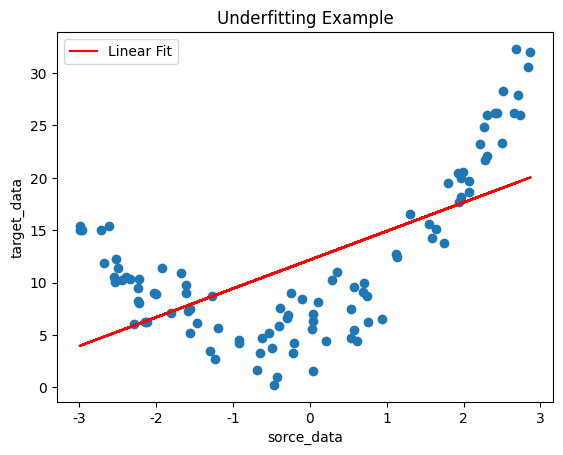

In [79]:
# 模拟欠拟合
line_model = LinearRegression(fit_intercept=True)
line_model.fit(X, target_data)
y_pred = line_model.predict(X)

# 特征维度太少，无法捕捉数据的复杂关系，导致欠拟合
title_text = "欠拟合示例" if selected_font else "Underfitting Example"
plt.scatter(sorce_data, target_data, marker='o')
plt.plot(sorce_data, y_pred, color='red', label='Linear Fit')
plt.title(title_text)
plt.xlabel("sorce_data")
plt.ylabel("target_data")
plt.legend()
plt.show()

多项式特征样本: [[ 0.1037873   0.0107718 ]
 [ 2.68177562  7.19192049]
 [ 1.59275856  2.53687982]
 [-1.30562494  1.70465647]
 [-1.67372782  2.80136482]]
多项式特征形状: (100, 2)


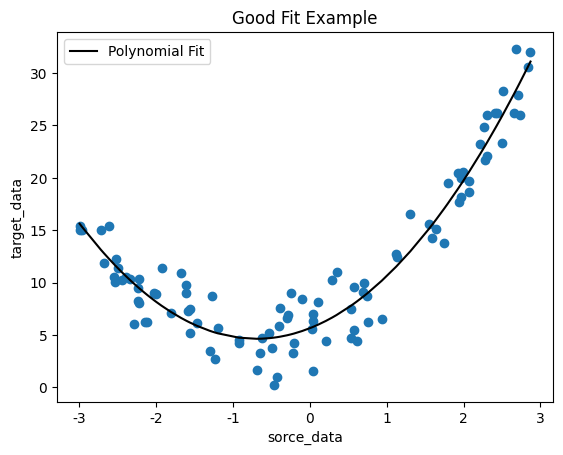

In [80]:
# 模拟正常拟合

# 增加特征
poly_features = np.hstack([X, X**2]) # 横向拼接
print("多项式特征样本:", poly_features[:5])
print("多项式特征形状:", poly_features.shape)

line_model.fit(poly_features, target_data)
y_pred_poly = line_model.predict(poly_features)


# 按 x 排序后再画线
idx = np.argsort(sorce_data)
x_sorted = sorce_data[idx]
y_sorted = y_pred_poly[idx]

title_text = "正常拟合示例" if selected_font else "Good Fit Example"
plt.scatter(sorce_data, target_data, marker='o')
plt.plot(x_sorted, y_sorted, color='black', label='Polynomial Fit')
plt.title(title_text)
plt.xlabel("sorce_data")
plt.ylabel("target_data")
plt.legend()
plt.show()

多项式特征样本: [[ 1.03787303e-01  1.07718043e-02  1.11797652e-03  1.16031767e-04
   1.20426242e-05  1.24987149e-06  1.29720791e-07  1.34633711e-08
   1.39732697e-09  1.45024798e-10]
 [ 2.68177562e+00  7.19192049e+00  1.92871171e+01  5.17237204e+01
   1.38711412e+02  3.71992884e+02  9.97601449e+02  2.67534325e+03
   7.17467030e+03  1.92408559e+04]
 [ 1.59275856e+00  2.53687982e+00  4.04063704e+00  6.43575922e+00
   1.02506106e+01  1.63267477e+01  2.60045671e+01  4.14189967e+01
   6.59704614e+01  1.05075017e+02]
 [-1.30562494e+00  1.70465647e+00 -2.22564200e+00  2.90585369e+00
  -3.79395504e+00  4.95348231e+00 -6.46739003e+00  8.44398569e+00
  -1.10246783e+01  1.43940949e+01]
 [-1.67372782e+00  2.80136482e+00 -4.68872223e+00  7.84764484e+00
  -1.31348215e+01  2.19841161e+01 -3.67954268e+01  6.15855295e+01
  -1.03077414e+02  1.72523536e+02]]
多项式特征形状: (100, 10)


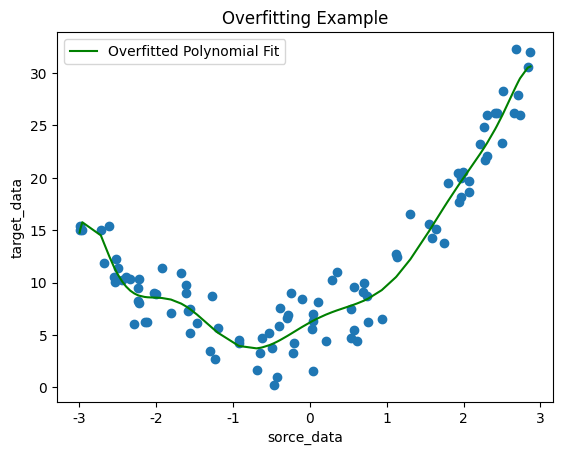

In [81]:
# 模拟过拟合

# 特征过多,模型过于复杂，捕捉了数据中的噪声，导致过拟合
poly_features = np.hstack([X**i for i in range(1, 11)]) # 1阶到10阶特征
print("多项式特征样本:", poly_features[:5])
print("多项式特征形状:", poly_features.shape)

line_model.fit(poly_features, target_data)
y_pred_poly = line_model.predict(poly_features)
# 按 x 排序后再画线
idx = np.argsort(sorce_data)
x_sorted = sorce_data[idx]
y_sorted = y_pred_poly[idx]
title_text = "过拟合示例" if selected_font else "Overfitting Example"
plt.scatter(sorce_data, target_data, marker='o')
plt.plot(x_sorted, y_sorted, color='green', label='Overfitted Polynomial Fit')
plt.title(title_text)
plt.xlabel("sorce_data")
plt.ylabel("target_data")
plt.legend()